Saving predictive analysiss.xls to predictive analysiss.xls
MAE: 24.944134078212375
MSE: 728.3309691616447
R² Score: 0.9856502217109133


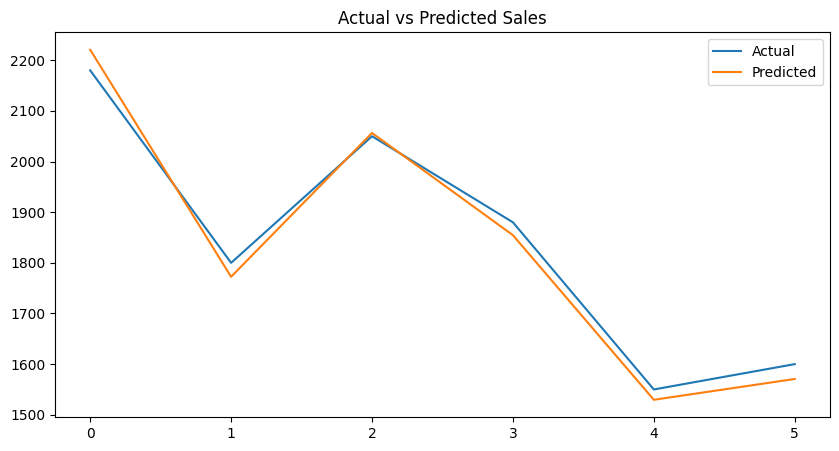

         Date  Predicted_Sales
0  2024-01-31      2299.300678
1  2024-02-01      1264.788080
2  2024-02-02      1305.847537
3  2024-02-03      1346.906995
4  2024-02-04      1387.966452
5  2024-02-05      1384.480817
6  2024-02-06      1425.540275
7  2024-02-07      1466.599732
8  2024-02-08      1507.659189
9  2024-02-09      1548.718647
10 2024-02-10      1589.778104
11 2024-02-11      1630.837561
12 2024-02-12      1627.351927
13 2024-02-13      1668.411384
14 2024-02-14      1709.470841
15 2024-02-15      1750.530299
16 2024-02-16      1791.589756
17 2024-02-17      1832.649213
18 2024-02-18      1873.708671
19 2024-02-19      1870.223036
20 2024-02-20      1911.282493
21 2024-02-21      1952.341951
22 2024-02-22      1993.401408
23 2024-02-23      2034.460865
24 2024-02-24      2075.520323
25 2024-02-25      2116.579780
26 2024-02-26      2113.094145
27 2024-02-27      2154.153603
28 2024-02-28      2195.213060
29 2024-02-29      2236.272517


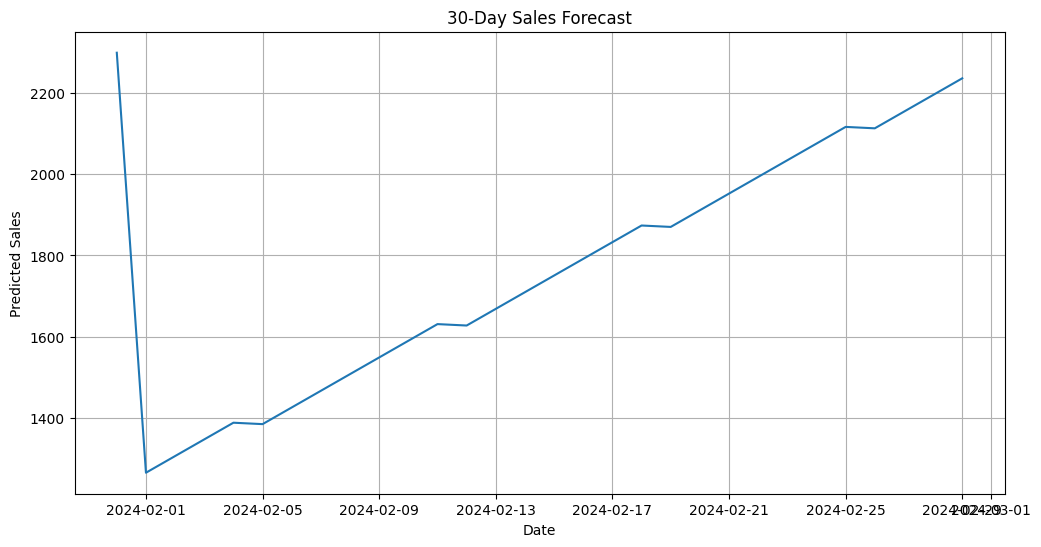

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)

df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

X = df[['Year', 'Month', 'Day', 'DayOfWeek']]
y = df['sale']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("R² Score:", r2_score(y_test, predictions))

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

future_dates = pd.date_range(
    start=df['Date'].max() + pd.Timedelta(days=1),
    periods=30
)

future_df = pd.DataFrame({'Date': future_dates})

future_df['Year'] = future_df['Date'].dt.year
future_df['Month'] = future_df['Date'].dt.month
future_df['Day'] = future_df['Date'].dt.day
future_df['DayOfWeek'] = future_df['Date'].dt.dayofweek

future_df['Predicted_Sales'] = model.predict(
    future_df[['Year', 'Month', 'Day', 'DayOfWeek']]
)

print(future_df[['Date', 'Predicted_Sales']])

plt.figure(figsize=(12,6))
plt.plot(future_df['Date'], future_df['Predicted_Sales'])
plt.title("30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.show()